In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score
from tqdm import tqdm
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import OneCycleLR
import gc
import matplotlib.pyplot as plt
from util import seed_everything, count_parameters, plot_all_model_losses, get_metrics_array
from networks import SpatialViT, SpatialViTMatched, AttentionUNet, SwinTransformer
from loader import load_ixi_data, BalancedDataset

# Configuration
MNI_DIR = os.path.expanduser('~/SpectralViT/data/IXI_extracted/')
CSV_PATH = os.path.expanduser('~/SpectralViT/data/IXI_extracted/IXI.csv')
VOL_SIZE = 96
N_COMP = 128
EPOCHS = 500
LR = 1e-4
BATCH_SIZE = 8
N_FOLDS = 5
device = torch.device("cuda:5" if torch.cuda.is_available() else "cpu")

seed_everything(0)

In [2]:
# Load data
X, Y = load_ixi_data(MNI_DIR, CSV_PATH, VOL_SIZE)
X_flat = X.reshape(len(X), -1)

print(f"Loaded {len(X)} samples")
print(f"Volume shape: {X.shape}")
print(f"Labels: {np.bincount(Y.astype(int))}")
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=0)

Loading Data: 100%|██████████| 581/581 [01:32<00:00,  6.27it/s]


Loaded 566 samples
Volume shape: (566, 96, 96, 96)
Labels: [254 312]


In [3]:
from networks_common import SpectralViT  # Import from the unified library

# Spectral ViT 
spectral_vit_history = {'spectral_vit_loss': []}
oof_probs_spec = []
oof_y_true = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X_flat), 1):
    print(f"Starting Spectral ViT Fold {fold}...")
    torch.cuda.empty_cache()
    
    # Fit PCA on training data
    pca = PCA(n_components=N_COMP, whiten=True).fit(X_flat[train_idx])
    
    # Transform data
    tr_pca = torch.from_numpy(pca.transform(X_flat[train_idx])).float()
    tr_y = torch.from_numpy(Y[train_idx]).float()
    ts_pca = torch.from_numpy(pca.transform(X_flat[test_idx])).float().to(device)
    ts_y = torch.from_numpy(Y[test_idx]).float().to(device)
    
    loader = DataLoader(TensorDataset(tr_pca, tr_y), batch_size=BATCH_SIZE, shuffle=True)
    
    # Initialize model from networks_common
    # Defaults in common are: n_heads=2, n_layers=4, pooling='mean', use_sigmoid=False
    # This exactly matches your original IXI SpectralViT implementation.
    model = SpectralViT(
        n_inputs=N_COMP, 
        embed_dim=16, 
        use_mode_weights=True
    ).to(device)
    
    opt = optim.AdamW(model.parameters(), lr=LR)
    sched = OneCycleLR(opt, max_lr=LR, steps_per_epoch=len(loader), epochs=EPOCHS)
    crit = nn.BCEWithLogitsLoss()
    
    # Training loop
    spectral_vit_fold_losses = []
    for epoch in range(EPOCHS):
        model.train()
        epoch_loss_spectral_vit = 0
        for b_pca, b_y in loader:
            b_pca, b_y = b_pca.to(device), b_y.to(device)
            opt.zero_grad()
            
            # The unified model returns logits by default, matching BCEWithLogitsLoss
            loss = crit(model(b_pca), b_y)
            
            loss.backward()
            epoch_loss_spectral_vit += loss.item()
            opt.step()
            sched.step()

        if (epoch + 1) % 10 == 0:
            model.eval()
            with torch.no_grad():
                # We apply sigmoid here for metric calculation, same as original
                probs = torch.sigmoid(model(ts_pca)).cpu().numpy()
                auc = roc_auc_score(ts_y.cpu(), probs)
                preds = (probs > 0.5).astype(int)
                acc = np.mean(preds == ts_y.cpu().numpy()) * 100
                print(f"Fold {fold} | Epoch {epoch+1:3d} | Spec AUC: {auc:.4f} (Acc: {acc:.2f}%)")
                
        spectral_vit_fold_losses.append(epoch_loss_spectral_vit / len(loader))
    spectral_vit_history['spectral_vit_loss'].append(spectral_vit_fold_losses)

    # Final evaluation
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(ts_pca)).cpu().numpy()
        oof_probs_spec.append(probs)
        oof_y_true.append(ts_y.cpu().numpy())

# Get parameter count
params_spec = count_parameters(model)
print(f"Spectral ViT parameters: {params_spec:,}")

Starting Spectral ViT Fold 1...
Fold 1 | Epoch  10 | Spec AUC: 0.4873 (Acc: 60.53%)
Fold 1 | Epoch  20 | Spec AUC: 0.5222 (Acc: 60.53%)
Fold 1 | Epoch  30 | Spec AUC: 0.5694 (Acc: 60.53%)
Fold 1 | Epoch  40 | Spec AUC: 0.6332 (Acc: 60.53%)
Fold 1 | Epoch  50 | Spec AUC: 0.6899 (Acc: 60.53%)
Fold 1 | Epoch  60 | Spec AUC: 0.7159 (Acc: 60.53%)
Fold 1 | Epoch  70 | Spec AUC: 0.7742 (Acc: 66.67%)
Fold 1 | Epoch  80 | Spec AUC: 0.8573 (Acc: 78.07%)
Fold 1 | Epoch  90 | Spec AUC: 0.8776 (Acc: 81.58%)
Fold 1 | Epoch 100 | Spec AUC: 0.8837 (Acc: 82.46%)
Fold 1 | Epoch 110 | Spec AUC: 0.8963 (Acc: 81.58%)
Fold 1 | Epoch 120 | Spec AUC: 0.8857 (Acc: 84.21%)
Fold 1 | Epoch 130 | Spec AUC: 0.8976 (Acc: 83.33%)
Fold 1 | Epoch 140 | Spec AUC: 0.8921 (Acc: 84.21%)
Fold 1 | Epoch 150 | Spec AUC: 0.8966 (Acc: 83.33%)
Fold 1 | Epoch 160 | Spec AUC: 0.8957 (Acc: 84.21%)
Fold 1 | Epoch 170 | Spec AUC: 0.8924 (Acc: 79.82%)
Fold 1 | Epoch 180 | Spec AUC: 0.8957 (Acc: 83.33%)
Fold 1 | Epoch 190 | Spec AUC: 0

In [4]:
from networks_common import SpatialViT  # Import from unified library

# Spatial ViT Configuration
PHYSICAL_BATCH_SIZE = 2
EFFECTIVE_BATCH_SIZE = 8
ACCUMULATION_STEPS = EFFECTIVE_BATCH_SIZE // PHYSICAL_BATCH_SIZE

spatial_vit_history = {'spatial_vit_loss': []}
oof_probs_spat = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X), 1):
    print(f"Starting Spatial ViT Fold {fold}...")
    torch.cuda.empty_cache()
    
    # Data preparation
    tr_vol = torch.from_numpy(X[train_idx]).unsqueeze(1).float()
    tr_y = torch.from_numpy(Y[train_idx]).float()
    ts_vol = torch.from_numpy(X[test_idx]).unsqueeze(1).float().to(device)
    ts_y = torch.from_numpy(Y[test_idx]).float().to(device)
    
    loader = DataLoader(TensorDataset(tr_vol, tr_y), batch_size=PHYSICAL_BATCH_SIZE, shuffle=True)
    
    # Initialize from networks_common.py
    # Unified Defaults: is_2d=False, use_cls_token=True, n_heads=4, n_layers=2
    # These match your original IXI implementation exactly.
    model = SpatialViT(
        vol_size=VOL_SIZE, 
        patch_size=12, 
        embed_dim=128
    ).to(device)
    
    opt = optim.AdamW(model.parameters(), lr=LR)
    sched = OneCycleLR(opt, max_lr=LR, steps_per_epoch=len(loader)//ACCUMULATION_STEPS, epochs=EPOCHS)
    crit = nn.BCEWithLogitsLoss()
    
    spatial_vit_fold_losses = []
    for epoch in range(EPOCHS):
        model.train()
        epoch_loss_spatial_vit = 0
        for i, (b_vol, b_y) in enumerate(loader):
            b_vol, b_y = b_vol.to(device), b_y.to(device)
            
            # Forward pass (returns logits by default)
            logits = model(b_vol)
            loss = crit(logits, b_y) / ACCUMULATION_STEPS
            loss.backward()
            epoch_loss_spatial_vit += loss.item() * ACCUMULATION_STEPS

            if (i + 1) % ACCUMULATION_STEPS == 0:
                opt.step()
                sched.step()
                opt.zero_grad()
                
        if (epoch + 1) % 10 == 0:
            model.eval()
            with torch.no_grad():
                test_probs = []
                # Processing in chunks to avoid OOM
                for chunk in torch.split(ts_vol, PHYSICAL_BATCH_SIZE):
                    test_probs.append(torch.sigmoid(model(chunk)))
                probs = torch.cat(test_probs).cpu().numpy()
                auc = roc_auc_score(ts_y.cpu(), probs)
                acc = np.mean((probs > 0.5) == ts_y.cpu().numpy()) * 100
                print(f"Fold {fold} | Epoch {epoch+1:3d} | Spat AUC: {auc:.4f} (Acc: {acc:.2f}%)")
        
        spatial_vit_fold_losses.append(epoch_loss_spatial_vit / len(loader))
    
    spatial_vit_history['spatial_vit_loss'].append(spatial_vit_fold_losses)
    
    # Out-of-fold predictions
    model.eval()
    with torch.no_grad():
        test_probs = []
        for chunk in torch.split(ts_vol, PHYSICAL_BATCH_SIZE):
            test_probs.append(torch.sigmoid(model(chunk)))
        oof_probs_spat.append(torch.cat(test_probs).cpu().numpy())

# Parameter count and summary
params_spat = count_parameters(model)
print(f"Spatial ViT parameters: {params_spat:,}")

Starting Spatial ViT Fold 1...
Fold 1 | Epoch  10 | Spat AUC: 0.8129 (Acc: 60.53%)
Fold 1 | Epoch  20 | Spat AUC: 0.8393 (Acc: 60.53%)
Fold 1 | Epoch  30 | Spat AUC: 0.7556 (Acc: 63.16%)
Fold 1 | Epoch  40 | Spat AUC: 0.8499 (Acc: 75.44%)
Fold 1 | Epoch  50 | Spat AUC: 0.8815 (Acc: 79.82%)
Fold 1 | Epoch  60 | Spat AUC: 0.8947 (Acc: 76.32%)
Fold 1 | Epoch  70 | Spat AUC: 0.8866 (Acc: 78.95%)
Fold 1 | Epoch  80 | Spat AUC: 0.8554 (Acc: 76.32%)
Fold 1 | Epoch  90 | Spat AUC: 0.8799 (Acc: 78.07%)
Fold 1 | Epoch 100 | Spat AUC: 0.8377 (Acc: 75.44%)
Fold 1 | Epoch 110 | Spat AUC: 0.8548 (Acc: 75.44%)
Fold 1 | Epoch 120 | Spat AUC: 0.8605 (Acc: 80.70%)
Fold 1 | Epoch 130 | Spat AUC: 0.8232 (Acc: 72.81%)
Fold 1 | Epoch 140 | Spat AUC: 0.8171 (Acc: 68.42%)
Fold 1 | Epoch 150 | Spat AUC: 0.8209 (Acc: 74.56%)
Fold 1 | Epoch 160 | Spat AUC: 0.7807 (Acc: 63.16%)
Fold 1 | Epoch 170 | Spat AUC: 0.8071 (Acc: 71.93%)
Fold 1 | Epoch 180 | Spat AUC: 0.8528 (Acc: 77.19%)
Fold 1 | Epoch 190 | Spat AUC: 0.

In [5]:
# Compact Spatial ViT (Refactored to use unified SpatialViT class)
PHYSICAL_BATCH_SIZE = 2
EFFECTIVE_BATCH_SIZE = 8
ACCUMULATION_STEPS = EFFECTIVE_BATCH_SIZE // PHYSICAL_BATCH_SIZE

compact_spatial_vit_history = {'compact_spatial_vit_loss': []}
oof_probs_spat_matched = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X), 1):
    print(f"Starting Compact Spatial ViT Fold {fold}...")
    torch.cuda.empty_cache()
    
    # Data Preparation
    tr_vol = torch.from_numpy(X[train_idx]).unsqueeze(1).float()
    tr_y = torch.from_numpy(Y[train_idx]).float()
    ts_vol = torch.from_numpy(X[test_idx]).unsqueeze(1).float().to(device)
    ts_y = torch.from_numpy(Y[test_idx]).float().to(device)
    
    loader = DataLoader(TensorDataset(tr_vol, tr_y), batch_size=PHYSICAL_BATCH_SIZE, shuffle=True)
    
    # Using Unified SpatialViT with settings to match the ~28k parameter complexity:
    # use_cls_token=False uses mean pooling, matching the original "Matched" behavior.
    model = SpatialViT(
        vol_size=VOL_SIZE, 
        patch_size=12, 
        embed_dim=12, 
        n_heads=1, 
        n_layers=1, 
        is_2d=False, 
        use_cls_token=False
    ).to(device)
    
    opt = optim.AdamW(model.parameters(), lr=LR)
    sched = OneCycleLR(opt, max_lr=LR, steps_per_epoch=len(loader)//ACCUMULATION_STEPS, epochs=EPOCHS)
    crit = nn.BCEWithLogitsLoss()
    
    compact_spatial_vit_fold_losses = []
    for epoch in range(EPOCHS):
        model.train()
        epoch_loss_compact_spatial_vit = 0
        for i, (b_vol, b_y) in enumerate(loader):
            b_vol, b_y = b_vol.to(device), b_y.to(device)
            
            logits = model(b_vol)
            loss = crit(logits, b_y) / ACCUMULATION_STEPS
            loss.backward()
            
            epoch_loss_compact_spatial_vit += loss.item() * ACCUMULATION_STEPS
            
            if (i + 1) % ACCUMULATION_STEPS == 0:
                opt.step()
                sched.step()
                opt.zero_grad()

        if (epoch + 1) % 10 == 0:
            model.eval()
            with torch.no_grad():
                test_probs = []
                for chunk in torch.split(ts_vol, PHYSICAL_BATCH_SIZE):
                    # SpatialViT returns logits by default when return_logit=False 
                    # and use_sigmoid=False (default)
                    test_probs.append(torch.sigmoid(model(chunk)))
                probs = torch.cat(test_probs).cpu().numpy()
                auc = roc_auc_score(ts_y.cpu(), probs)
                print(f"Fold {fold} | Epoch {epoch+1:3d} | Matched AUC: {auc:.4f}")
        
        compact_spatial_vit_fold_losses.append(epoch_loss_compact_spatial_vit / len(loader))
    
    compact_spatial_vit_history['compact_spatial_vit_loss'].append(compact_spatial_vit_fold_losses)

    # Final Inference
    model.eval()
    with torch.no_grad():
        test_probs = []
        for chunk in torch.split(ts_vol, PHYSICAL_BATCH_SIZE):
            test_probs.append(torch.sigmoid(model(chunk)))
        oof_probs_spat_matched.append(torch.cat(test_probs).cpu().numpy())

params_match = sum(p.numel() for p in model.parameters())
print(f"\nMatched Spatial ViT parameters: {params_match:,}")

Starting Compact Spatial ViT Fold 1...
Fold 1 | Epoch  10 | Matched AUC: 0.5417
Fold 1 | Epoch  20 | Matched AUC: 0.6409
Fold 1 | Epoch  30 | Matched AUC: 0.7031
Fold 1 | Epoch  40 | Matched AUC: 0.7156
Fold 1 | Epoch  50 | Matched AUC: 0.7346
Fold 1 | Epoch  60 | Matched AUC: 0.7691
Fold 1 | Epoch  70 | Matched AUC: 0.7791
Fold 1 | Epoch  80 | Matched AUC: 0.7671
Fold 1 | Epoch  90 | Matched AUC: 0.7903
Fold 1 | Epoch 100 | Matched AUC: 0.7559
Fold 1 | Epoch 110 | Matched AUC: 0.7098
Fold 1 | Epoch 120 | Matched AUC: 0.6699
Fold 1 | Epoch 130 | Matched AUC: 0.6403
Fold 1 | Epoch 140 | Matched AUC: 0.6061
Fold 1 | Epoch 150 | Matched AUC: 0.6164
Fold 1 | Epoch 160 | Matched AUC: 0.6093
Fold 1 | Epoch 170 | Matched AUC: 0.6061
Fold 1 | Epoch 180 | Matched AUC: 0.5968
Fold 1 | Epoch 190 | Matched AUC: 0.5884
Fold 1 | Epoch 200 | Matched AUC: 0.5829
Fold 1 | Epoch 210 | Matched AUC: 0.5768
Fold 1 | Epoch 220 | Matched AUC: 0.6812
Fold 1 | Epoch 230 | Matched AUC: 0.6087
Fold 1 | Epoch 240

In [6]:
# Training
oof_probs_swin = []
kf = KFold(n_splits=5, shuffle=True, random_state=0)
swin_history = {'swin_loss': []}
for fold, (train_idx, test_idx) in enumerate(kf.split(X)):
    tr_vol = torch.from_numpy(X[train_idx]).unsqueeze(1).float()
    tr_y = torch.from_numpy(Y[train_idx]).float()
    ts_vol = torch.from_numpy(X[test_idx]).unsqueeze(1).float().to(device)
    ts_y = torch.from_numpy(Y[test_idx]).float().to(device)
    train_loader = DataLoader(BalancedDataset(tr_vol, tr_y), batch_size=BATCH_SIZE, shuffle=True)
    
    # img_size=96, patch_size=8, res=12, divisible by window_size=6
    m_swin = SwinTransformer(img_size=X.shape[-1], patch_size=8, window_size=6).to(device)
    optimizer = optim.AdamW(m_swin.parameters(), lr=1e-4,)
    criterion = nn.BCEWithLogitsLoss()

    print(f"Starting Swin Fold {fold+1}...")
    fold_swin_losses = []
    for epoch in range(1, EPOCHS + 1):
        m_swin.train()
        epoch_loss_swin = 0
        for b_vol, b_y in train_loader:
            b_vol, b_y = b_vol.to(device), b_y.to(device)
            optimizer.zero_grad()
            l_swin = criterion(m_swin(b_vol + torch.randn_like(b_vol)*0.01), b_y)
            l_swin.backward()
            optimizer.step()
            epoch_loss_swin += l_swin.item()
        
        # Save average epoch loss
        fold_swin_losses.append(epoch_loss_swin / len(train_loader))
    swin_history['swin_loss'].append(fold_swin_losses)

    with torch.no_grad():
        m_swin.eval()
        logits = m_swin(ts_vol)
        oof_probs_swin.append(torch.sigmoid(logits).cpu().numpy())
    
    del m_swin; gc.collect(); torch.cuda.empty_cache()

# Results
p_swin_final = np.concatenate(oof_probs_swin)
preds_swin = (p_swin_final > 0.5).astype(int)

params_swin = sum(p.numel() for p in
                   SwinTransformer(img_size=X.shape[-1], patch_size=8, window_size=6).to(device).parameters() 
                   if p.requires_grad)
print(f"Swin Parameters: {params_swin:,}")

Starting Swin Fold 1...
Starting Swin Fold 2...
Starting Swin Fold 3...
Starting Swin Fold 4...
Starting Swin Fold 5...
Swin Parameters: 19,457


In [7]:
# U-net
unet_history = {'unet_loss': []}
oof_probs_unet = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X)):
    print(f"Starting Attention U-Net Fold {fold+1}...")
    torch.cuda.empty_cache()
    
    # Data
    tr_vol = torch.from_numpy(X[train_idx]).unsqueeze(1).float()
    tr_y = torch.from_numpy(Y[train_idx]).float()
    ts_vol = torch.from_numpy(X[test_idx]).unsqueeze(1).float().to(device)
    ts_y = torch.from_numpy(Y[test_idx]).float().to(device)
    
    # Use your original BATCH_SIZE (e.g., 8) for speed
    train_loader = DataLoader(TensorDataset(tr_vol, tr_y), batch_size=BATCH_SIZE, shuffle=True)
    
    # Identical Model call
    m_unet = AttentionUNet(in_channels=1, base_channels=7).to(device)
    optimizer = optim.AdamW(m_unet.parameters(), lr=1e-4)
    criterion = nn.BCEWithLogitsLoss()

    fold_unet_losses = []
    for epoch in range(1, EPOCHS + 1):
        m_unet.train()
        epoch_loss_unet = 0
        for b_vol, b_y in train_loader:
            b_vol, b_y = b_vol.to(device), b_y.to(device)
            optimizer.zero_grad()
            loss = criterion(m_unet(b_vol), b_y)
            loss.backward()
            optimizer.step()
            epoch_loss_unet += loss.item()
        
        fold_unet_losses.append(epoch_loss_unet / len(train_loader))
    unet_history['unet_loss'].append(fold_unet_losses)

    # Fast Inference
    m_unet.eval()
    with torch.no_grad():
        # Using a loop for inference to prevent OOM on the test set
        test_probs = []
        for chunk in torch.split(ts_vol, PHYSICAL_BATCH_SIZE):
            test_probs.append(torch.sigmoid(m_unet(chunk)))
        oof_probs_unet.append(torch.cat(test_probs).cpu().numpy())

params_unet = sum(p.numel() for p in m_unet.parameters())
print(f"U-Net Parameters: {params_unet:,}")

Starting Attention U-Net Fold 1...
Starting Attention U-Net Fold 2...
Starting Attention U-Net Fold 3...
Starting Attention U-Net Fold 4...
Starting Attention U-Net Fold 5...
U-Net Parameters: 14,382


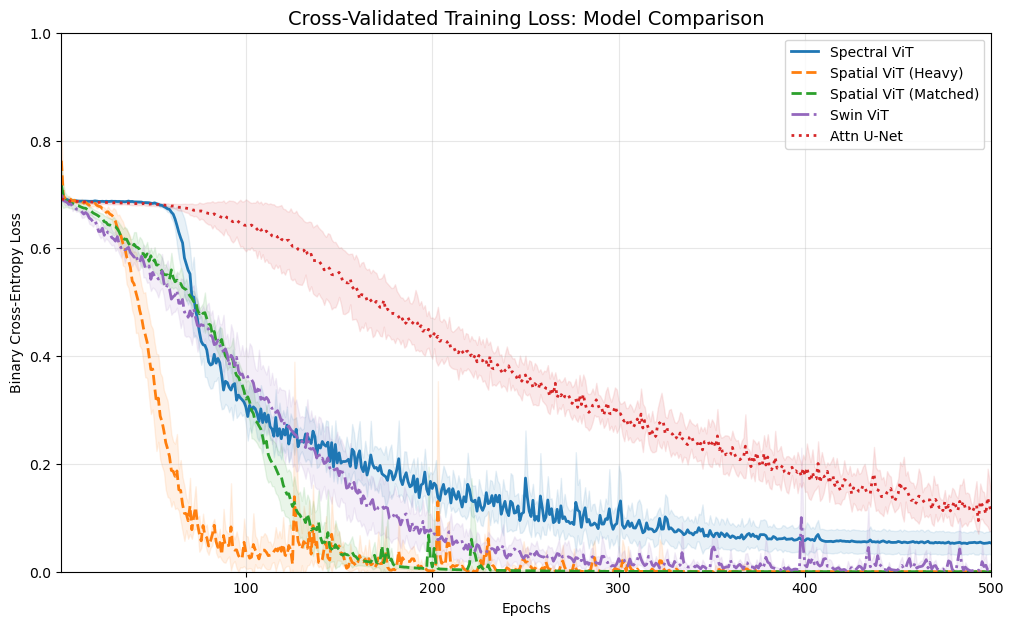

In [8]:
plot_all_model_losses(spectral_vit_history, spatial_vit_history, compact_spatial_vit_history, unet_history, swin_history, EPOCHS)

In [9]:
# Compute overall metrics
y_final = np.concatenate(oof_y_true)
p_spec_final = np.concatenate(oof_probs_spec)
p_spat_final = np.concatenate(oof_probs_spat)
p_match_final = np.concatenate(oof_probs_spat_matched)
p_unet_final = np.concatenate(oof_probs_unet)
spec_metrics = get_metrics_array(y_final, p_spec_final)
spat_metrics = get_metrics_array(y_final, p_spat_final)
match_metrics = get_metrics_array(y_final, p_match_final)
unet_metrics = get_metrics_array(y_final, p_unet_final)

# Compute per-fold variation
spec_fold_metrics = [get_metrics_array(oof_y_true[f], oof_probs_spec[f]) for f in range(N_FOLDS)]
spat_fold_metrics = [get_metrics_array(oof_y_true[f], oof_probs_spat[f]) for f in range(N_FOLDS)]
match_fold_metrics = [get_metrics_array(oof_y_true[f], oof_probs_spat_matched[f]) for f in range(N_FOLDS)]
unet_fold_metrics = [get_metrics_array(oof_y_true[f], oof_probs_unet[f]) for f in range(N_FOLDS)]
spec_std = np.std(spec_fold_metrics, axis=0)
spat_std = np.std(spat_fold_metrics, axis=0)
match_std = np.std(match_fold_metrics, axis=0)
unet_std = np.std(unet_fold_metrics, axis=0)

# Print 
col_width = 22
print("\n" + "="*110)
print(f"{'Metric':<15} | {'Spectral ViT':^{col_width}} | {'Spat-ViT (H)':^{col_width}} | {'Spat-ViT (M)':^{col_width}} | {'Attn U-Net':^{col_width}}")
print("-" * 110)

metric_names = ['Accuracy', 'Sensitivity', 'Specificity', 'AUC']
for i, name in enumerate(metric_names):
    spec_str  = f"{spec_metrics[i]:.3f} ± {spec_std[i]:.3f}"
    spat_str  = f"{spat_metrics[i]:.3f} ± {spat_std[i]:.3f}"
    match_str = f"{match_metrics[i]:.3f} ± {match_std[i]:.3f}"
    unet_str  = f"{unet_metrics[i]:.3f} ± {unet_std[i]:.3f}"
    print(f"{name:<15} | {spec_str:^{col_width}} | {spat_str:^{col_width}} | {match_str:^{col_width}} | {unet_str:^{col_width}}")

print("-" * 110)
print(f"{'Parameters':<15} | {params_spec:^{col_width},} | {params_spat:^{col_width},} | {params_match:^{col_width},} | {params_unet:^{col_width},}")
print("="*110)


Metric          |      Spectral ViT      |      Spat-ViT (H)      |      Spat-ViT (M)      |       Attn U-Net      
--------------------------------------------------------------------------------------------------------------
Accuracy        |     0.804 ± 0.023      |     0.694 ± 0.038      |     0.610 ± 0.055      |     0.647 ± 0.129     
Sensitivity     |     0.856 ± 0.065      |     0.747 ± 0.068      |     0.644 ± 0.058      |     0.551 ± 0.376     
Specificity     |     0.740 ± 0.089      |     0.630 ± 0.086      |     0.567 ± 0.080      |     0.764 ± 0.212     
AUC             |     0.836 ± 0.032      |     0.730 ± 0.044      |     0.645 ± 0.075      |     0.715 ± 0.018     
--------------------------------------------------------------------------------------------------------------
Parameters      |         13,169         |        552,449         |         28,213         |         14,382        
